# 002 - Stage 2: fine-tuned inverse decoder $D^{-1}$

Stage 1 used each family's **original encoder** $E$ as the decoder inverse $D^{-1}$. Stage 2 keeps everything else from Stage 1 (signals, score selection, decision rule, metrics) and only replaces $E$ by a **fine-tuned inverse decoder**, as in Zhao et al. (Sec. 3, Eq. 6; App. C, Table A1).

**Why.** The signals assume $D^{-1}$ inverts the decoder: for an image the family generated, $x_Z = D(f_Z)$, $D^{-1}(x_Z)$ should land back on $f_Z$, so QuantLoss and EncLoss are near zero. $E$ was trained on natural images, not on decoder outputs, so it is a poor inverse (paper Table 4; Stage 1 finding 2: QuantLoss AUC 0.52 for VAR, 0.71 for RAR).

**Fine-tuning objective (Eq. 6).** The generators give training pairs with a known answer:
$$t_Z \sim \text{IAR}(\cdot \mid c), \qquad f_Z = Q^{-1}(t_Z), \qquad x_Z = D(f_Z), \qquad \mathcal{L}_\text{inv} = \big\lVert f_Z - D^{-1}(x_Z) \big\rVert^2 .$$
$D^{-1}$ has the encoder's architecture and starts from its weights; the codebook $Q^{-1}$ and decoder $D$ stay frozen. For RAR, $f_Z$ is the 16×16 grid of codebook vectors of the 256 tokens. For VAR, $f_Z = \sum_{k=1}^{10}\phi_k(\mathrm{up}(Z[t_k]))$ over the 10 scales (680 tokens).

**Choices for this repo**
- **One $D^{-1}$ per family**, trained on an equal mix of all 4 sizes' samples, because the sizes share the tokenizer (the paper fine-tunes per model).
- **Sampling settings**: each repo's ImageNet FID settings (RAR per size; VAR `cfg=1.5, top_k=900, top_p=0.96`). The task's own settings are unknown, so this is an assumption.
- **8-bit images**: $x_Z$ is stored as uint8 with the repos' own saving rule ($\lfloor 255x \rfloor$), matching the task PNGs.
- **No augmentation**, and a **shortened run** first (fewer images and epochs than the paper); scale up only if it helps.
- Fine-tuning sees only generated images. Task train images are used only to monitor, and task val only to evaluate at the end, as in Stage 1.

**Pipeline** (`scripts/run_stage2.sh`, run in tmux; logs in `/workspace/cache/stage2/logs/`)
1. `scripts/generate_finetune_data.py`: sample $(t_Z, x_Z)$ pairs from every generator → `stage2/gen/`
2. `scripts/finetune_inverse.py`: fine-tune $D^{-1}$ per family → `stage2/inv/<family>/` (`log.csv`, `final.pt`)
3. `scripts/extract_features.py --inv-ckpt .../final.pt`: Stage 1 signals with $D^{-1}$ → `stage2/features/`
4. This notebook: validate steps 1–3, then the Stage 1 decision rule on the new features.

## Setup

In [1]:
import sys, json
from pathlib import Path
REPO = Path("/workspace/iar-model-tracer")
sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import roc_auc_score

from tracer.common import CACHE, LABELS, FAMILY_OF, build_index, free
from tracer.generate import MODELS, to_uint8
from tracer.inverse import (LOAD_TOKENIZER, evaluate_generated, load_generated, load_inverse, quantize,
                            split_holdout, target)
from tracer.stage1 import NearestFamilyThreshold, KNOWN_FAMILIES
from tracer.metrics import report, confusion, family_confusion

S1 = CACHE / "stage1"  # Stage 1: features, metrics and submission with the original encoders
S2 = CACHE / "stage2"  # Stage 2: gen/, inv/<family>/, features/, logs/
GEN, INV, FEAT = S2 / "gen", S2 / "inv", S2 / "features"
# Fine-tuning settings of the run shown here (written by scripts/finetune_inverse.py).
CFG = {fam: json.loads((INV / fam / "config.json").read_text()) for fam in KNOWN_FAMILIES}
pd.set_option("display.precision", 3)
pd.set_option("display.width", 200)

## 1. Fine-tuning data

`generate_finetune_data.py` samples every generator of a family, with classes cycling through the 1000 ImageNet classes in a fixed random order. For each sample it stores the tokens $t_Z$, the class, and $x_Z = D(Q^{-1}(t_Z))$ as uint8. The RAR generator returns its tokens. VAR's `autoregressive_infer_cfg` only returns the image, so its tokens are captured at each scale's sampling call, and the image is decoded again in fp32 from those tokens.

Checks below:
1. counts per model and class coverage;
2. generated samples next to task train images of the same model (they should look alike);
3. stored images equal $D(Q^{-1}(t_Z))$ recomputed here, and how often re-quantizing $f_Z$ returns $t_Z$ (the best token accuracy any $D^{-1}$ can reach);
4. VAR only: the captured tokens reproduce the generator's own output image.

In [2]:
# Load the generated data of both families (tokens, uint8 images, classes, model label) and summarise per model.
gen = {fam: load_generated(GEN, fam) for fam in KNOWN_FAMILIES}
rows = []
for fam, d in gen.items():
    for lab in MODELS[fam]:
        m = d["label"] == lab
        rows.append({"family": fam, "model": lab, "images": int(m.sum()),
                     "distinct classes": len(np.unique(d["classes"][m])),
                     "tokens / image": d["tokens"].shape[1],
                     "token ids": f'{d["tokens"][m].min()}..{d["tokens"][m].max()}'})
display(pd.DataFrame(rows).set_index(["family", "model"]))
for fam in KNOWN_FAMILIES:
    print(fam, "generation config:", json.loads((GEN / fam / "config.json").read_text()))

images  distinct classes  tokens / image token ids
family model                                                     
rar    rarb      2560              1000             256   0..1023
       rarl      2560              1000             256   0..1023
       rarxl     2560              1000             256   0..1023
       rarxxl    2560              1000             256   0..1023
var    var16     2560              1000             680   0..4095
       var20     2560              1000             680   0..4095
       var24     2560              1000             680   0..4095
       var30     2560              1000             680   0..4095

rar generation config: {'family': 'rar', 'shard_size': 512, 'batch_size': 64, 'seed': 0}
var generation config: {'family': 'var', 'shard_size': 512, 'batch_size': 64, 'seed': 0}


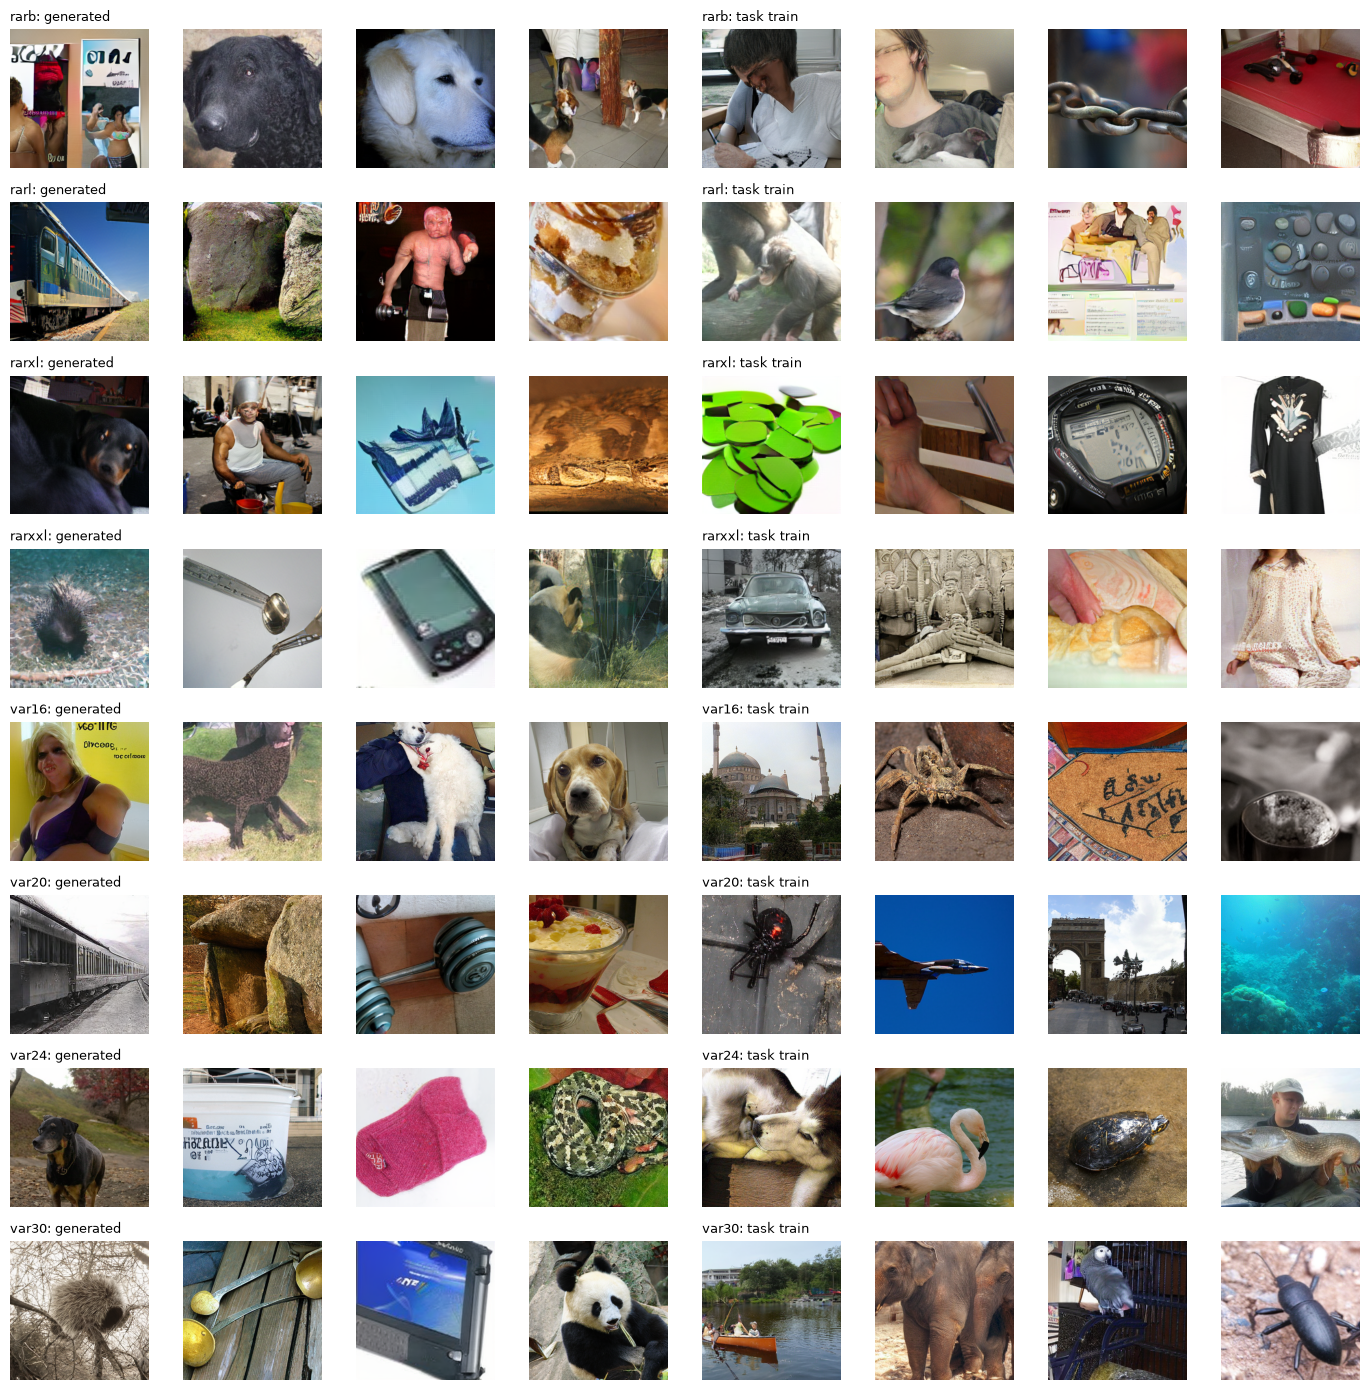

In [3]:
# Check 2: per model, 4 generated samples (left) next to 4 task train images of the same model (right).
idx = build_index()
real = idx[idx.split == "train"]
fig, axs = plt.subplots(8, 8, figsize=(14, 14))
for r, lab in enumerate(MODELS["rar"] + MODELS["var"]):
    d = gen[FAMILY_OF[lab]]
    for j, i in enumerate(np.where(d["label"] == lab)[0][:4]):
        axs[r, j].imshow(d["images"][i].transpose(1, 2, 0))
    for j, p in enumerate(real[real.label == lab].path.iloc[:4]):
        axs[r, 4 + j].imshow(plt.imread(p))
    axs[r, 0].set_title(f"{lab}: generated", fontsize=9, loc="left")
    axs[r, 4].set_title(f"{lab}: task train", fontsize=9, loc="left")
for a in axs.flat:
    a.axis("off")
plt.tight_layout(); plt.show()

In [4]:
# Check 3, on 64 samples per family spread over all models:
#   decode: stored image vs D(Q^-1(t_Z)) recomputed here, in uint8 levels. Generation uses TF32 convolutions (the
#           PyTorch default, also used by the repos' samplers), whose rounding depends on the batch shape: two decodes
#           of the same tokens differ by up to ~2 levels on ~2% of pixels. A wrong token/image pairing would differ
#           by tens of levels on average; the control pairs each stored image with the next sample's decode.
#   Q(f_Z) == t_Z: re-quantizing the exact target features. RAR's nearest-codebook lookup must return t_Z (1.0).
#           VAR's greedy multi-scale quantizer (Alg. 2) need not, so this is the ceiling for VAR token accuracy.
rows = []
for fam in KNOWN_FAMILIES:
    tok, d = LOAD_TOKENIZER[fam](), gen[fam]
    j = np.linspace(0, len(d["tokens"]) - 1, 64).astype(int)
    t = torch.from_numpy(d["tokens"][j]).cuda()
    with torch.no_grad():
        fz = target(tok, fam, t)
        x = tok.decoder(fz).clamp(0, 1) if fam == "rar" else (tok.fhat_to_img(fz) + 1) / 2
        idx_q, _ = quantize(tok, fam, fz)
    x8, stored = to_uint8(x).cpu().int(), torch.from_numpy(d["images"][j]).int()
    diff, wrong = (x8 - stored).abs(), (x8.roll(1, 0) - stored).abs()
    rows.append({"family": fam, "mean |diff| (levels)": diff.float().mean().item(), "max |diff|": diff.max().item(),
                 "pixels differing": f"{(diff > 0).float().mean().item():.2%}",
                 "control, wrong pairing: mean |diff|": wrong.float().mean().item(),
                 "Q(f_Z) == t_Z": (idx_q == t).float().mean().item()})
    del tok; free()
pd.DataFrame(rows).set_index("family")

attention mode is flash


/workspace/external/1d-tokenizer/modeling/modules/losses.py:141: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)


/workspace/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/workspace/external/1d-tokenizer/modeling/quantizer/quantizer.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/workspace/external/1d-tokenizer/modeling/quantizer/quantizer.py:134: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/workspace/external/1d-tokenizer/modeling/quantizer/quantizer.py:154: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/workspace/external/1d-tokenizer/modeling/quantizer/quantizer.py:159: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/workspace/external/1d-tokenizer/modeling/quantizer/quantizer.py:163: FutureWarning: `torch.cuda.amp.autocast(args...)` i

,mean |diff| (levels),max |diff|,pixels differing,"control, wrong pairing: mean |diff|",Q(f_Z) == t_Z
family,,,,,
rar,0.00,0,0.00%,84.800,1.000
var,0.01,1,1.02%,76.501,0.387


In [5]:
# Check 4 (VAR): sample 8 images from VAR-d16 and compare the generator's own output (fp16 autocast) with the image
# decoded in fp32 from the captured tokens. Wrong tokens would give completely different images, not small noise.
from tracer.generate import load_var_generator, sample_var
torch.manual_seed(0)
vae, var_gen = load_var_generator("var16")
t, img, gen_img = sample_var(vae, var_gen, torch.arange(8) * 125, return_generator_image=True)
d = (img.float() / 255 - gen_img.clamp(0, 1)).abs()
print(f"|image from captured tokens - generator output|: mean {d.mean():.4f}, max {d.max():.4f} (1 level = {1/255:.4f})")
del vae, var_gen; free()


[constructor]  ==== flash_if_available=True (0/16), fused_if_available=True (fusing_add_ln=0/16, fusing_mlp=0/16) ==== 
    [VAR config ] embed_dim=1024, num_heads=16, depth=16, mlp_ratio=4.0
    [drop ratios ] drop_rate=0.0, attn_drop_rate=0.0, drop_path_rate=0.0666667 (tensor([0.0000, 0.0044, 0.0089, 0.0133, 0.0178, 0.0222, 0.0267, 0.0311, 0.0356,
        0.0400, 0.0444, 0.0489, 0.0533, 0.0578, 0.0622, 0.0667]))



[init_weights] VAR with init_std=0.0180422


|image from captured tokens - generator output|: mean 0.0020, max 0.0103 (1 level = 0.0039)


## 2. Fine-tuning

`finetune_inverse.py` fine-tunes one $D^{-1}$ per family:
- **Model**: $D^{-1}$ = the tokenizer's encoder (RAR: `encoder`; VAR: `encoder` + `quant_conv`, input scaled to $[-1,1]$), initialised from $E$. Everything else is frozen.
- **Loss**: $\mathcal{L}_\text{inv}$ (Eq. 6), the MSE between $D^{-1}(x_Z)$ and $f_Z$, averaged over elements.
- **Optimiser**: Adam with StepLR (×0.9 every 2 epochs). The learning rate and batch size follow the paper's Table A1 (RAR $5\cdot10^{-4}$ / 8, VAR $5\cdot10^{-5}$ / 16); the image count and epochs are shortened (config below).
- **Held-out generated images**: the last `holdout_per_model` samples of each model are never trained on.

Logged after every epoch (`log.csv`; **epoch 0 is the original encoder $E$**):

| column | definition |
|---|---|
| `train_l_inv` | mean $\mathcal{L}_\text{inv}$ over the epoch's training batches |
| `holdout_l_inv` | $\mathcal{L}_\text{inv}$ on the held-out generated images |
| `holdout_tok_acc` | fraction of tokens recovered exactly, $Q(D^{-1}(x_Z)) = t_Z$ |
| `holdout_quant` | QuantLoss $\lVert D^{-1}(x) - Q^{-1}(Q(D^{-1}(x)))\rVert^2$ (Eq. 5) on held-out generated images |
| `train_auc_<signal>` | AUC of the family's Stage 1 signal on the **task train** images, own family vs the other family (higher = better separation; same definition as Stage 1) |

The task-train AUC is only a monitor: it uses train, never val, and the final checkpoint is used regardless (no early stopping).

In [6]:
# Fine-tuning configuration and per-epoch log of each family.
logs = {fam: pd.read_csv(INV / fam / "log.csv") for fam in KNOWN_FAMILIES}
for fam in KNOWN_FAMILIES:
    print(fam, {k: v for k, v in CFG[fam].items() if k not in ("family", "out")})
    display(logs[fam].set_index("epoch"))

rar {'data': '/workspace/cache/stage2/gen', 'max_per_model': None, 'holdout_per_model': 100, 'epochs': 10, 'batch_size': 8, 'lr': 0.0005, 'step_size': 2, 'gamma': 0.9, 'seed': 0, 'no_task_train_eval': False}


,train_l_inv,lr,holdout_l_inv,holdout_tok_acc,holdout_quant,train_auc_quant,train_auc_cal,train_auc_comb,train_auc_tok_match
epoch,,,,,,,,,
0,NaN,NaN,1.495,0.652,1.328,0.710,0.899,0.879,0.834
1,0.521,5.000e-04,0.466,0.788,0.384,0.995,0.928,0.979,0.665
2,0.440,5.000e-04,0.438,0.815,0.369,0.997,0.911,0.974,0.675
3,0.404,4.500e-04,0.422,0.830,0.360,0.997,0.921,0.976,0.690
4,0.381,4.500e-04,0.413,0.837,0.355,0.997,0.914,0.971,0.695
5,0.358,4.050e-04,0.403,0.848,0.349,0.998,0.940,0.981,0.675
6,0.340,4.050e-04,0.402,0.854,0.350,0.998,0.925,0.977,0.678
7,0.321,3.645e-04,0.400,0.856,0.349,0.998,0.943,0.990,0.694
8,0.307,3.645e-04,0.400,0.859,0.350,0.997,0.926,0.981,0.700


var {'data': '/workspace/cache/stage2/gen', 'max_per_model': None, 'holdout_per_model': 100, 'epochs': 5, 'batch_size': 16, 'lr': 5e-05, 'step_size': 2, 'gamma': 0.9, 'seed': 0, 'no_task_train_eval': False}


,train_l_inv,lr,holdout_l_inv,holdout_tok_acc,holdout_quant,train_auc_quant,train_auc_cal,train_auc_comb,train_auc_tok_match
epoch,,,,,,,,,
0,NaN,NaN,0.190,0.261,0.236,0.517,0.947,0.687,0.731
1,0.051,5.000e-05,0.045,0.253,0.092,0.783,0.975,0.975,0.834
2,0.043,5.000e-05,0.043,0.261,0.092,0.795,0.972,0.970,0.842
3,0.041,4.500e-05,0.041,0.265,0.092,0.814,0.982,0.982,0.858
4,0.040,4.500e-05,0.040,0.267,0.092,0.821,0.975,0.971,0.872
5,0.039,4.050e-05,0.040,0.271,0.092,0.826,0.980,0.980,0.870


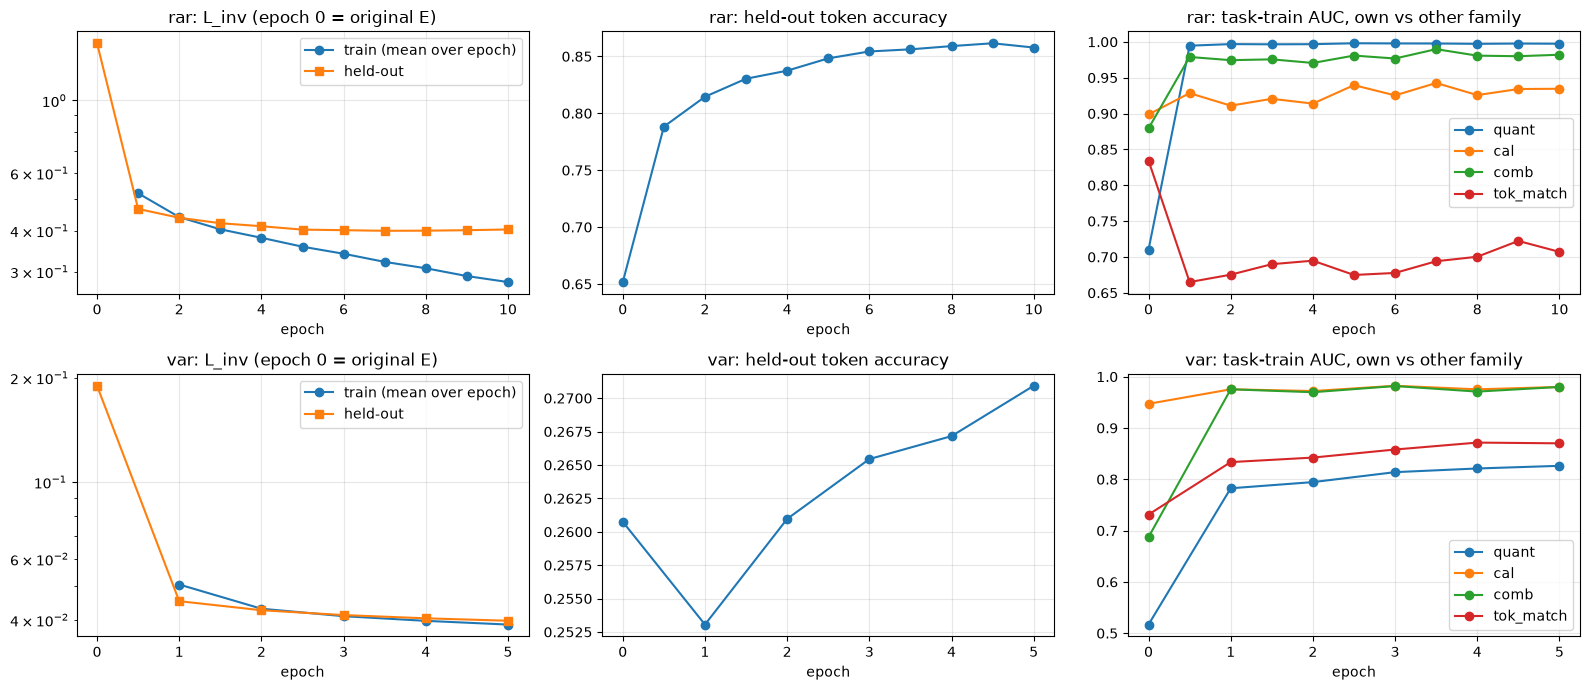

In [7]:
# Curves per family: L_inv (train vs held-out), held-out token accuracy, and task-train AUC of each signal.
fig, axs = plt.subplots(2, 3, figsize=(16, 7))
for row, fam in zip(axs, KNOWN_FAMILIES):
    lg = logs[fam]
    row[0].plot(lg.epoch, lg.train_l_inv, "o-", label="train (mean over epoch)")
    row[0].plot(lg.epoch, lg.holdout_l_inv, "s-", label="held-out")
    row[0].set_yscale("log"); row[0].set_title(f"{fam}: L_inv (epoch 0 = original E)"); row[0].legend()
    row[1].plot(lg.epoch, lg.holdout_tok_acc, "o-")
    row[1].set_title(f"{fam}: held-out token accuracy")
    for c in [c for c in lg.columns if c.startswith("train_auc_")]:
        row[2].plot(lg.epoch, lg[c], "o-", label=c.replace("train_auc_", ""))
    row[2].set_title(f"{fam}: task-train AUC, own vs other family"); row[2].legend()
for a in axs.flat:
    a.set_xlabel("epoch"); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Original $E$ vs fine-tuned $D^{-1}$ on held-out generated images

The same held-out images as in the log, broken down by generator size, for $E$ and for `final.pt`. A better inverse has lower $\mathcal{L}_\text{inv}$ and QuantLoss, and higher token accuracy (for VAR, compare with the `Q(f_Z) == t_Z` ceiling from check 3).

In [8]:
# Rebuild the exact training / held-out split of the run (same data dir, max_per_model, holdout_per_model).
rows = []
for fam in KNOWN_FAMILIES:
    data = load_generated(CFG[fam]["data"], fam, max_per_model=CFG[fam]["max_per_model"])
    _, hold = split_holdout(data, CFG[fam]["holdout_per_model"])
    tok = LOAD_TOKENIZER[fam]()
    for name, ckpt in [("E (original)", None), ("D^-1 (fine-tuned)", INV / fam / "final.pt")]:
        if ckpt:
            load_inverse(tok, fam, ckpt)  # replaces the encoder weights in place
        for lab in MODELS[fam]:
            m = hold["label"] == lab
            rows.append({"family": fam, "model": lab, "inverse": name,
                         **evaluate_generated(tok, fam, {k: v[m] for k, v in hold.items()})})
    del tok, data; free()
inv_eval = pd.DataFrame(rows)
inv_eval.pivot_table(index=["family", "model"], columns="inverse", values=["l_inv", "tok_acc", "quant"])

attention mode is flash


/workspace/external/1d-tokenizer/modeling/modules/losses.py:141: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/workspace/external/1d-tokenizer/modeling/quantizer/quantizer.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/workspace/external/1d-tokenizer/modeling/quantizer/quantizer.py:134: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/workspace/external/1d-tokenizer/modeling/quantizer/quantizer.py:154: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/workspace/external/1d-tokenizer/modeling/quantizer/quantizer.py:159: FutureWarning: `torch.cuda.amp.autocast(args...)` is dep

l_inv                          quant                        tok_acc             
inverse       D^-1 (fine-tuned) E (original) D^-1 (fine-tuned) E (original) D^-1 (fine-tuned) E (original)
family model                                                                                              
rar    rarb               0.398        1.475             0.348        1.306             0.857        0.648
       rarl               0.407        1.495             0.353        1.319             0.857        0.642
       rarxl              0.400        1.479             0.349        1.322             0.859        0.665
       rarxxl             0.409        1.532             0.357        1.365             0.858        0.652
var    var16              0.040        0.188             0.092        0.233             0.273        0.254
       var20              0.041        0.194             0.093        0.241             0.273        0.262
       var24              0.039        0.178             0.091        0.226             0.273        0.266
       var30              0.040        0.198             0.092        0.246             0.267        0.261

## 4. Stage 2 features and sanity checks

`extract_features.py --inv-ckpt` computes the Stage 1 signals (Stage 1 notebook, *Signals*) with $D^{-1}$ loaded in place of $E$, for all 11,050 images. Checks:
1. the features were computed with this run's `final.pt`;
2. the rows match the image index and the Stage 1 rows exactly;
3. the same feature checks as Stage 1: no NaNs, positive losses, and the `_greedy` duplicates are dropped (the token search is still off, `--var-iters 0`).

**`enc2` → 0.** $\mathrm{Rec}(x) = D(\dots)$ is always a decoder output, whatever $x$ is. A $D^{-1}$ that inverts $D$ well therefore re-encodes $\mathrm{Rec}(x)$ to exactly the same tokens, and then $\mathrm{Rec}(\mathrm{Rec}(x)) = \mathrm{Rec}(x)$ and `enc2` $= 0$. This happened during RAR fine-tuning (epoch 5) and made `cal = enc1/enc2` infinite. `signals.py` now floors `enc2` at $10^{-10}$, below every non-zero value seen (Stage 1 minimum $1.7\cdot10^{-8}$), so Stage 1 values are unchanged. The cell below counts the images at the floor. The complexity estimate behind the calibrated EncLoss becomes uninformative as $D^{-1}$ improves, so `cal` is expected to lose signal in Stage 2.

In [9]:
def load_features(d):
    # Join the per-family feature tables on key (as in Stage 1).
    rar, var = pd.read_csv(d / "rar.csv"), pd.read_csv(d / "var.csv")
    return rar.merge(var.drop(columns=["split", "label", "family", "name"]), on="key", validate="1:1")

# 1. Stage 2 features come from this run's fine-tuned checkpoints.
for fam in KNOWN_FAMILIES:
    fcfg = json.loads((FEAT / fam / "config.json").read_text())
    assert fcfg["inv_ckpt"] == str(INV / fam / "final.pt") and fcfg["var_iters"] == 0, fcfg
    print(fam, "features computed with", fcfg["inv_ckpt"])

# 2. Same rows, in the same order, as the image index and Stage 1.
df1, df = load_features(S1), load_features(FEAT)
idx = build_index()
assert df.key.tolist() == idx.key.tolist() == df1.key.tolist()
assert (df.label.dropna() == idx.label.dropna()).all()

# 3. Feature checks and deduplication, exactly as in Stage 1.
FEATS = [c for c in df.columns if c[:4] in ("rar_", "var_")]
assert df[FEATS].notna().all().all() and (df[FEATS].drop(columns=["rar_tok_match", "var_tok_match"]) > 0).all().all()
assert np.allclose(df.var_quant, df.var_quant_greedy) and np.allclose(df.var_comb, df.var_comb_greedy)
FEATS = [c for c in FEATS if c not in ("var_quant_greedy", "var_comb_greedy")]

train, val, test = (df[df.split == s].reset_index(drop=True) for s in ["train", "val", "test"])
train1, val1 = (df1[df1.split == s].reset_index(drop=True) for s in ["train", "val"])  # Stage 1, for comparison
print({s: len(d) for s, d in [("train", train), ("val", val), ("test", test)]})
print("features:", FEATS)

# Images whose enc2 hit the floor (Rec(Rec(x)) == Rec(x) exactly), per stage and family, over all 11,050 images.
from tracer.signals import ENC2_MIN
print("enc2 at floor:", {f"{name} {fam}": int((d[f"{fam}_enc2"] <= ENC2_MIN).sum())
                         for name, d in [("Stage 1", df1), ("Stage 2", df)] for fam in KNOWN_FAMILIES})

rar features computed with /workspace/cache/stage2/inv/rar/final.pt
var features computed with /workspace/cache/stage2/inv/var/final.pt


{'train': 800, 'val': 450, 'test': 9800}
features: ['rar_quant', 'rar_quant_p90', 'rar_enc1', 'rar_enc2', 'rar_cal', 'rar_comb', 'rar_tok_match', 'var_quant', 'var_enc1', 'var_enc2', 'var_cal', 'var_comb', 'var_tok_match']
enc2 at floor: {'Stage 1 rar': 0, 'Stage 1 var': 0, 'Stage 2 rar': 4, 'Stage 2 var': 0}


## 5. Choosing each family's score (train only)

The same rule as Stage 1: AUC with losses signed as $-\log s$ (higher = own family), and the score $s_f$ is the loss with the highest **train** AUC, own family vs the other family. The Stage 1 train AUC is shown next to it. Val columns are for reference only.

*Run-to-run noise:* feature extraction uses TF32 convolutions (PyTorch's default), whose rounding depends on the batch shape and cuDNN's algorithm choice. VAR's greedy residual quantization amplifies it, because a token flipped at a coarse scale changes every later scale. Measured on VAR train images, `var_cal` changes by a median 3.7% between batch sizes 32 and 8 with TF32, versus ~0 with TF32 off. Recomputing the Stage 1 VAR features moved the `var_cal` train AUC by about 0.005. RAR signals reproduce to about 0.001. Stage 1 and Stage 2 use the same settings, so the comparison is like for like, but differences of this size are noise.

In [10]:
def signed(d, c):
    return d[c].values if c.endswith("tok_match") else -np.log(d[c].values)  # higher = more likely own family

rows = []
for fam in KNOWN_FAMILIES:
    for c in [c for c in FEATS if c.startswith(fam + "_")]:
        vo = val[val.family.isin([fam, "outlier"])]
        rows.append({"family": fam, "signal": c,
                     "Stage 1 train AUC": roc_auc_score(train1.family == fam, signed(train1, c)),
                     "train AUC own vs other fam": roc_auc_score(train.family == fam, signed(train, c)),
                     "val AUC own vs rest": roc_auc_score(val.family == fam, signed(val, c)),
                     "val AUC own vs outlier": roc_auc_score(vo.family == fam, signed(vo, c))})
auc = pd.DataFrame(rows).set_index(["family", "signal"])
display(auc)

# Selection as in Stage 1: a loss (lower = own family), highest Stage 2 train AUC.
loss_like = auc[~auc.index.get_level_values("signal").str.endswith("tok_match")]
SCORE = {fam: loss_like.loc[fam]["train AUC own vs other fam"].idxmax() for fam in KNOWN_FAMILIES}
SCORE1 = json.loads((S1 / "metrics.json").read_text())["score_cols"]
print("selected scores:", SCORE, "| Stage 1:", SCORE1)

Stage 1 train AUC  train AUC own vs other fam  val AUC own vs rest  val AUC own vs outlier
family signal                                                                                                   
rar    rar_quant                  0.710                       0.997                0.999                   0.998
       rar_quant_p90              0.689                       0.987                0.988                   0.979
       rar_enc1                   0.766                       0.917                0.918                   0.891
       rar_enc2                   0.608                       0.647                0.689                   0.691
       rar_cal                    0.900                       0.935                0.921                   0.894
       rar_comb                   0.880                       0.982                0.976                   0.963
       rar_tok_match              0.835                       0.707                0.739                   0.857
var    var_quant                  0.517                       0.826                0.753                   0.538
       var_enc1                   0.545                       0.598                0.575                   0.603
       var_enc2                   0.420                       0.439                0.418                   0.463
       var_cal                    0.945                       0.983                0.972                   0.968
       var_comb                   0.687                       0.982                0.968                   0.939
       var_tok_match              0.731                       0.873                0.931                   0.953

selected scores: {'rar': 'rar_quant', 'var': 'var_cal'} | Stage 1: {'rar': 'rar_cal', 'var': 'var_cal'}


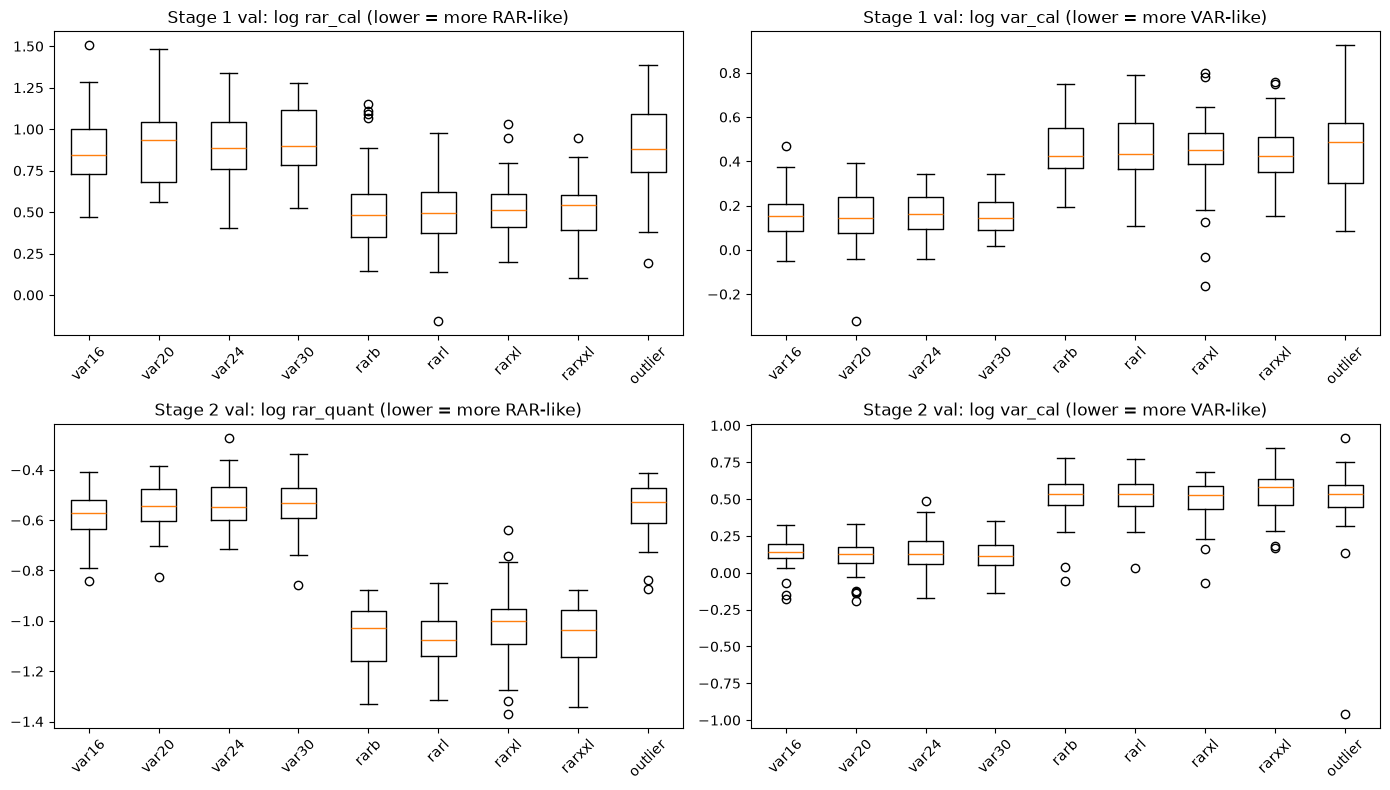

In [11]:
# Selected score by true val label: Stage 1 (top) vs Stage 2 (bottom). Lower = more like the family; the outlier
# threshold needs the family's own 4 sizes low and the other family + outliers high.
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
for r, (name, d, score) in enumerate([("Stage 1", val1, SCORE1), ("Stage 2", val, SCORE)]):
    for ax, fam in zip(axs[r], KNOWN_FAMILIES):
        c = score[fam]
        ax.boxplot([np.log(d[d.label == l][c]) for l in LABELS], tick_labels=LABELS)
        ax.set_title(f"{name} val: log {c} (lower = more {fam.upper()}-like)")
        ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## 6. Decision rule

Unchanged from Stage 1 (see that notebook for the full derivation): $z_f = (\log s_f - \mu_f)/\sigma_f$ with $\mu_f, \sigma_f$ from family $f$'s train images; family $\hat f = \arg\min_f z_f$; outlier if $z_{\hat f} > \tau_{\hat f}$, the train q-quantile; size by a per-family logistic regression on all 13 features. **q = 0.95**, fixed in advance as in Stage 1.

tau: {'rar': np.float64(1.606), 'var': np.float64(1.602)}


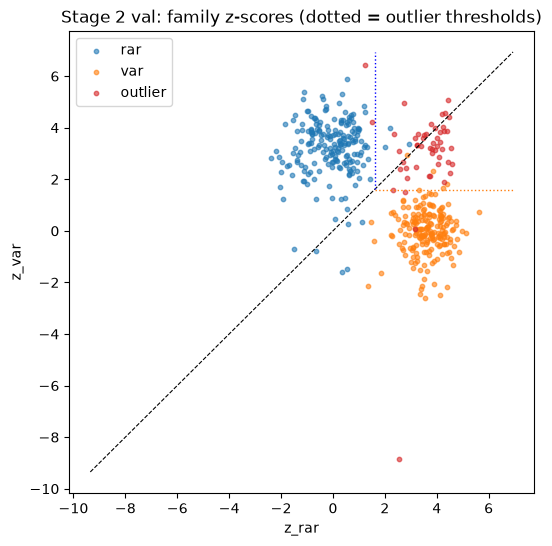

In [12]:
Q = 0.95
model = NearestFamilyThreshold(SCORE, q=Q, size_cols=FEATS).fit(train)
print("tau:", {k: round(v, 3) for k, v in model.tau_.items()})

# Val images at (z_rar, z_var), coloured by true family; same layout as in Stage 1.
z = model.family_z(val).assign(label=val.label, family=val.family)
fig, ax = plt.subplots(figsize=(6, 6))
for fam, col in [("rar", "tab:blue"), ("var", "tab:orange"), ("outlier", "tab:red")]:
    s = z[z.family == fam]
    ax.scatter(s.z_rar, s.z_var, s=10, alpha=0.6, c=col, label=fam)
lim = [min(z.z_rar.min(), z.z_var.min()) - 0.5, max(z.z_rar.max(), z.z_var.max()) + 0.5]
ax.plot(lim, lim, "k--", lw=0.8)  # family boundary
ax.plot([model.tau_["rar"], model.tau_["rar"]], [model.tau_["rar"], lim[1]], "b:", lw=1)  # RAR outlier threshold
ax.plot([model.tau_["var"], lim[1]], [model.tau_["var"], model.tau_["var"]], ":", c="tab:orange", lw=1)  # VAR
ax.set_xlabel("z_rar"); ax.set_ylabel("z_var"); ax.set_title("Stage 2 val: family z-scores (dotted = outlier thresholds)")
ax.legend(); plt.show()

## 7. Results, compared with Stage 1

Metrics as defined in Stage 1 (`tracer.metrics.report`). The Stage 1 column comes from `stage1/metrics.json`, the same q and rule with the original encoders. The family-level and full-label confusion matrices are for Stage 2 val.

In [13]:
pred_train, pred_val = model.predict(train), model.predict(val)
m1 = json.loads((S1 / "metrics.json").read_text())
res = pd.DataFrame({"Stage 1 val": m1["val"], "Stage 2 train (in-sample)": report(train.label, pred_train),
                    "Stage 2 val": report(val.label, pred_val)})
res["val change"] = res["Stage 2 val"] - res["Stage 1 val"]
display(res)
display(family_confusion(val.label, pred_val))
display(confusion(val.label, pred_val))

,Stage 1 val,Stage 2 train (in-sample),Stage 2 val,val change
n,450.000,800.000,450.000,0.000
accuracy,0.236,0.309,0.316,0.080
family_accuracy,0.838,0.946,0.960,0.122
outlier_recall,0.320,NaN,0.880,0.560
outlier_precision,0.533,0.000,0.863,0.329
size_accuracy_given_family,0.249,0.326,0.253,0.003
family_recall_rar,0.925,0.943,0.960,0.035
family_recall_var,0.880,0.950,0.980,0.100
family_recall_outlier,0.320,NaN,0.880,0.560


pred,rar,var,outlier
true,,,
rar,192,5,3
var,0,196,4
outlier,2,4,44


pred,var16,var20,var24,var30,rarb,rarl,rarxl,rarxxl,outlier
true,,,,,,,,,
var16,13,9,15,13,0,0,0,0,0
var20,16,9,12,12,0,0,0,0,1
var24,11,8,15,14,0,0,0,0,2
var30,14,7,16,12,0,0,0,0,1
rarb,1,0,0,0,13,9,17,10,0
rarl,1,0,0,0,12,13,15,9,0
rarxl,2,0,0,0,14,8,15,8,3
rarxxl,1,0,0,0,18,7,16,8,0
outlier,0,1,1,2,1,1,0,0,44


### Diagnostic: sensitivity to q (val)
As in Stage 1, refit for each q and evaluate on val. For reference only; q stays 0.95.

In [14]:
sweep = {q: report(val.label, NearestFamilyThreshold(SCORE, q=q, size_cols=FEATS).fit(train).predict(val))
         for q in [0.8, 0.85, 0.9, 0.95, 0.975, 0.99]}
pd.DataFrame(sweep).T[["accuracy", "family_accuracy", "outlier_recall", "outlier_precision",
                       "family_recall_rar", "family_recall_var"]]

,accuracy,family_accuracy,outlier_recall,outlier_precision,family_recall_rar,family_recall_var
0.800,0.304,0.862,0.96,0.466,0.850,0.850
0.850,0.313,0.887,0.96,0.522,0.875,0.880
0.900,0.313,0.942,0.94,0.723,0.945,0.940
0.950,0.316,0.960,0.88,0.863,0.960,0.980
0.975,0.313,0.962,0.86,0.896,0.960,0.990
0.990,0.291,0.944,0.64,0.941,0.970,0.995


## 8. Test predictions and run summary
The train-fit model is applied to the 9,800 test images and saved as `stage2/submission_stage2.csv`, with the same submission checks as Stage 1. Predicted family shares are compared with Stage 1's test predictions and with val. The run's settings and metrics go to `stage2/metrics.json`.

In [15]:
pred_test = model.predict(test)
sub = pd.DataFrame({"image_name": test.name, "label": pred_test})
assert len(sub) == 9800 and sub.image_name.is_unique and sub.image_name.str.endswith(".png").all()
assert sub.label.isin(LABELS).all()
sub.to_csv(S2 / "submission_stage2.csv", index=False)
print(S2 / "submission_stage2.csv")

sub1 = pd.read_csv(S1 / "submission_stage1.csv")
assert (sub1.image_name.values == sub.image_name.values).all()
print(f"test labels changed vs Stage 1: {(sub1.label.values != sub.label.values).mean():.1%}")
display(pd.DataFrame({"test Stage 2": pred_test.map(FAMILY_OF).value_counts(normalize=True),
                      "test Stage 1": sub1.label.map(FAMILY_OF).value_counts(normalize=True),
                      "val pred Stage 2": pred_val.map(FAMILY_OF).value_counts(normalize=True),
                      "val true": val.family.value_counts(normalize=True)}))

/workspace/cache/stage2/submission_stage2.csv
test labels changed vs Stage 1: 64.6%


,test Stage 2,test Stage 1,val pred Stage 2,val true
outlier,0.399,0.214,0.113,0.111
rar,0.278,0.453,0.431,0.444
var,0.323,0.333,0.456,0.444


In [16]:
# Save the run's configuration and metrics, as in Stage 1.
summary = {"finetune": CFG, "score_cols": SCORE, "q": Q, "tau": model.tau_, "size_features": FEATS,
           "val": res["Stage 2 val"].to_dict(), "train": res["Stage 2 train (in-sample)"].to_dict()}
(S2 / "metrics.json").write_text(json.dumps(summary, indent=2, default=float))

1755

## Findings

Shortened run: 2,560 generated images per model (10,240 per family, 100 per model held out); RAR 10 epochs and VAR 5 epochs at the paper's learning rate and batch size; no augmentation. Val, q = 0.95:

| metric | Stage 1 | Stage 2 |
|---|---|---|
| overall accuracy | 23.6% | 31.6% |
| family accuracy (RAR / VAR / outlier) | 83.8% | **96.0%** |
| family recall RAR / VAR | 92.5% / 88.0% | 96.0% / 98.0% |
| outlier recall / precision | 32.0% / 53.3% | **88.0% / 86.3%** |
| size accuracy given correct family | 24.9% | 25.3% (chance 25%) |

1. **The run checks out.** Each model has 2,560 samples covering all 1,000 classes, and the samples look like the task images of the same model. The stored images reproduce $D(Q^{-1}(t_Z))$: exactly for RAR, and within 1 level on 1% of pixels for VAR (TF32 rounding). A wrong token/image pairing would differ by 77–85 levels. The captured VAR tokens reproduce the generator's own output to half a level on average.
2. **Fine-tuning makes $D^{-1}$ a much better inverse, equally for all 4 sizes.** On held-out generated images:
   - $\mathcal{L}_\text{inv}$: 1.50 → 0.40 (RAR), 0.19 → 0.040 (VAR).
   - QuantLoss: 1.33 → 0.35 (RAR), 0.24 → 0.09 (VAR).
   - RAR token accuracy: 0.65 → 0.86.

   VAR token accuracy barely moves (0.26 → 0.27), but that is not a useful measure for VAR: its greedy quantizer recovers only 39% of the tokens even from the exact $f_Z$.
3. **RAR QuantLoss becomes a near-perfect family signal.** Its AUC rises from 0.71 to 0.997 on train, with 0.999 on val (own vs rest) and 0.998 (own vs outlier). It is now the selected RAR score, as in the paper. For VAR:
   - The calibrated EncLoss improves from 0.945 to 0.983 on train and stays the selected score.
   - VAR QuantLoss rises from 0.52 to 0.83 but hardly separates outliers on val (0.54). The paper pairs VAR QuantLoss with the optimized token search (Alg. 3), which is still off here (`--var-iters 0`).
4. **RAR $D^{-1}$ starts to overfit.** Held-out $\mathcal{L}_\text{inv}$ plateaus at about 0.40 from epoch 5, while the training loss keeps falling (0.36 → 0.28). When scaling up, more generated images matter more than more epochs. VAR is still improving slowly after 5 epochs.
5. **A better inverse has expected side effects.** RAR `tok_match` falls (0.835 → 0.707). For 4 RAR images, `enc2` became exactly 0: $\mathrm{Rec}(x)$ is always a decoder output, so a good $D^{-1}$ re-encodes it exactly. The run crashed on this once, at RAR epoch 5. It was resumed from epoch 4 after the `enc2` floor was added (log rows 5–10 are from the resumed run), and the RAR features were re-extracted with the floor.
6. **Sizes are still not separated** (25.3%, chance). This is the Stage 3 problem.
7. **Test differs from val.** 39.9% of test images are predicted outlier: val has 11.3% predicted (11.1% true), and Stage 1 predicted 21.4% on test. 64.6% of test labels changed from Stage 1. Test z-scores are higher than val's for both families (25th percentile: $z_\text{rar}$ 1.05 vs 0.22, $z_\text{var}$ 0.67 vs 0.08), so test images look less typical of both families. Either test has many more outliers than val, or it is shifted from train and val (for example, different generation settings). The outlier thresholds come from train only, so this is the main risk to the test score and worth investigating before scaling up.
8. **The gains are well above the noise.** TF32 noise moves the VAR `cal` AUC by about 0.005, while the Stage 2 changes above are larger.